## Step 1: Read the file

In [1]:
import pandas as pd
df = pd.read_csv('bigmart.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [2]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='str')

In [3]:
df.shape

(8523, 12)

## Step 2: Impute missing values

In [4]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB


In [6]:
df.Outlet_Size.value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [7]:
mean = df['Item_Weight'].mean()
df['Item_Weight']= df['Item_Weight'].fillna(mean, inplace =True)
print(mean)

mode = df['Outlet_Size'].mode()
print(mode[0])
df['Outlet_Size']=df['Outlet_Size'].fillna(mode[0], inplace = True)

12.857645184135977
Medium


C:\Users\HP\AppData\Local\Temp\ipykernel_13988\1334187770.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Item_Weight']= df['Item_Weight'].fillna(mean, inplace =True)
C:\Users\HP\AppData\Local\Temp\ipykernel_13988\1334187770.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained 

In [8]:

mean_weight = df['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)
print(mean_weight)

mode_size = df['Outlet_Size'].mode()[0]
print(mode_size)
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_size)

12.857645184135977
Medium


## Step 3: Deal with categorical variables and drop the id columns

In [9]:
df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Fat_Content           8523 non-null   str    
 2   Item_Visibility            8523 non-null   float64
 3   Item_Type                  8523 non-null   str    
 4   Item_MRP                   8523 non-null   float64
 5   Outlet_Establishment_Year  8523 non-null   int64  
 6   Outlet_Size                8523 non-null   str    
 7   Outlet_Location_Type       8523 non-null   str    
 8   Outlet_Type                8523 non-null   str    
 9   Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(5)
memory usage: 1.0 MB


In [11]:
obj_col_list = df.select_dtypes(include='str').columns.tolist()
print(obj_col_list)

['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [12]:
for i in obj_col_list:
   
    print(df[i].value_counts())
    print('-'*50)

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
--------------------------------------------------
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
--------------------------------------------------
Outlet_Size
Medium    5203
Small     2388
High       932
Name: count, dtype: int64
--------------------------------------------------
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64
---------------------------------

In [13]:
df.loc[df['Item_Fat_Content']=='Low Fat','Item_Fat_Content']='low fat'

df.loc[df['Item_Fat_Content']=='LF','Item_Fat_Content']='low fat'

df.loc[df['Item_Fat_Content']=='reg','Item_Fat_Content']='Regular'

In [14]:
for i in obj_col_list:
    print(df[i].value_counts())
    print('-'*50)

Item_Fat_Content
low fat    5517
Regular    3006
Name: count, dtype: int64
--------------------------------------------------
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
--------------------------------------------------
Outlet_Size
Medium    5203
Small     2388
High       932
Name: count, dtype: int64
--------------------------------------------------
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64
--------------------------------------------------
Outlet_Type
Supermarket Type1 

In [15]:
df = pd.get_dummies(df,drop_first=True)

In [16]:
df.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_low fat,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,True,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,443.4228,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,1999,2097.2700,True,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,1998,732.3800,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,8.93,0.000000,53.8614,1987,994.7052,True,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


## Step 4: Create a train and a test set

In [17]:
from sklearn.model_selection import train_test_split
train , test = train_test_split(df, test_size = 0.3)

x_train =train.drop('Item_Outlet_Sales', axis = 1 )
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales', axis = 1)
y_test = test['Item_Outlet_Sales']

## Step 5: Preprocessing – Scaling the features

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

x_train = pd.DataFrame(
    x_train_scaled,
    columns=x_train.columns,
    index=x_train.index
)

x_test = pd.DataFrame(
    x_test_scaled,
    columns=x_test.columns,
    index=x_test.index
)

## Step 6: Let’s examine the error rate for different k values.

In [19]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

In [20]:
rmse_val = [] 
for K in range(2,20):
   
    model = neighbors.KNeighborsRegressor(n_neighbors = K)

    model.fit(x_train, y_train)  
    pred=model.predict(x_test) 
    error = sqrt(mean_squared_error(y_test,pred)) 
    rmse_val.append(error) 
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  2 is: 1374.4399265723985
RMSE value for k=  3 is: 1289.3970055654465
RMSE value for k=  4 is: 1257.4450016507942
RMSE value for k=  5 is: 1242.4991257271897
RMSE value for k=  6 is: 1235.5553539104785
RMSE value for k=  7 is: 1225.6990888977116
RMSE value for k=  8 is: 1232.7638615051183
RMSE value for k=  9 is: 1240.6417734179006
RMSE value for k=  10 is: 1245.1126467603674
RMSE value for k=  11 is: 1245.9457242344088
RMSE value for k=  12 is: 1251.4554012956385
RMSE value for k=  13 is: 1257.50347411688
RMSE value for k=  14 is: 1260.0226873018048
RMSE value for k=  15 is: 1262.8007566851381
RMSE value for k=  16 is: 1268.9398931498972
RMSE value for k=  17 is: 1273.6592652584184
RMSE value for k=  18 is: 1277.5137913327546
RMSE value for k=  19 is: 1281.0142409330142


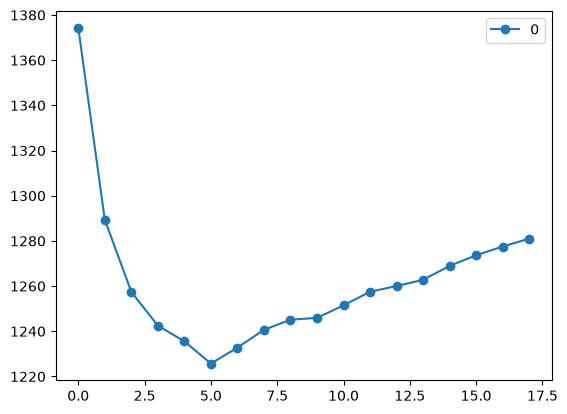

In [21]:
curve = pd.DataFrame(rmse_val)
curve.plot(marker = 'o')
plt.show()

## Step 7 Create final KNN model with best K

In [22]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=7)

knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)